# Sunpy SDO data

## 1. Prerrequisites

In [5]:
import warnings

from pathlib import Path

import numpy as np

from sunpy.net import Fido, attrs as a
import sunpy.map
from astropy.coordinates import SkyCoord

from astropy import units as u
from astropy.io import fits
from astropy.io.fits.verify import VerifyWarning


import matplotlib.pyplot as plt


## 2. Search the data

According to the paper, the plot corresponds to the following observation and phenomena

```txt
HMI continuum intensity images of an M5.3 WLF observed
at 09:54:53 UT on July 4, 2012. Panel a: normal intensity;
panel b: pseudo-intensity. Red arrows point out the regions where
the WL enhancements occurred.
```

Let's download the observation from that date through the SDO sunpy API.

In [ ]:
print(a.Instrument.hmi)

<sunpy.net.attrs.Instrument(HMI: Helioseismic and Magnetic Imager) object at 0x7f6f1834f2f0>


In [7]:
from datetime import datetime, timedelta
date = datetime.strptime("2012-07-04T09:54:53Z", "%Y-%m-%dT%H:%M:%SZ")
start_date = date - timedelta(seconds=20)
end_date = date + timedelta(seconds=20)
start_date_str = start_date.strftime("%Y-%m-%dT%H:%M:%SZ")
end_date_str = end_date.strftime("%Y-%m-%dT%H:%M:%SZ")
print(start_date, end_date)

# jsoc_instrument_name = 'hmi.ic_45s'
# band = "continuum"
# results = Fido.search(a.Time(start_date_str, end_date_str),
#             a.jsoc.Series(jsoc_instrument_name),
#             a.jsoc.Segment(band),
#             a.jsoc.Notify("juagudeloo@unal.edu.co"))

instrument = a.Instrument.hmi
hmi_data = Fido.search(a.Time(start_date_str, end_date_str),
            instrument
            )

hmi_cont = hmi_data["vso"][hmi_data["vso"]["Physobs"] == "intensity"]

download_path = Path("./data/sunpy_images/")
download_path.mkdir(parents=True, exist_ok=True)
# filename = date.strftime("%Y-%m-%dT%H:%M:%SZ") + f"_{jsoc_instrument_name.replace('.', '_').upper()}_{band}.fits"
filename = date.strftime("%Y-%m-%dT%H:%M:%SZ") + f"_{instrument.value.replace('.', '_').upper()}_CONTINUUM.fits"
file_path = download_path / filename

hmi_data = Fido.search(a.Time(start_date_str, end_date_str),
            instrument)
download_files = Fido.fetch(hmi_cont, path=file_path)


2012-07-04 09:54:33 2012-07-04 09:55:13


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [8]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=VerifyWarning)
    amap = sunpy.map.Map(download_files[0])

coord = SkyCoord(100 * u.arcsec, 10*u.arcsec, frame=amap.coordinate_frame)
coord

<SkyCoord (Helioprojective: obstime=2012-07-04T09:55:03.000, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2012-07-04T09:55:03.000, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.09346381, 3.280761, 1.52114554e+11)>): (Tx, Ty) in arcsec
    (100., 10.)>

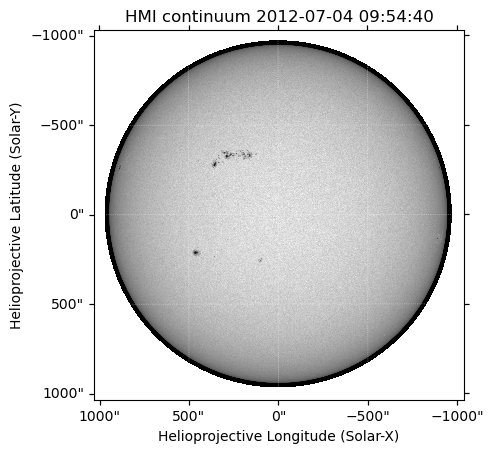

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = plt.subplot(projection=amap)
amap.plot()

Let's select by hand the region that corresponds to the region that we want our code to match with the plot from the paper.

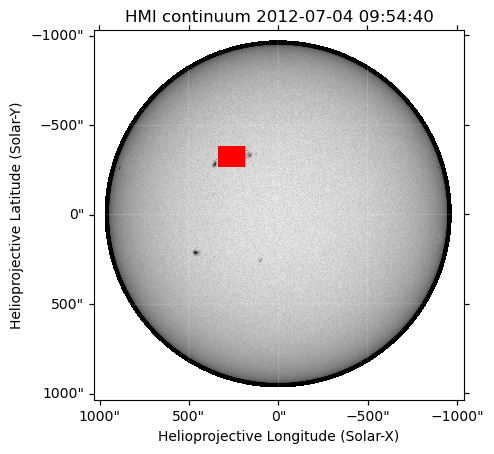

In [22]:
# Define the pixel range
ymin, ymax = 2600, 2800 # rows (y-axis)
xmin, xmax = 1380, 1650  # columns (x-axis)

# Create a grid of pixel coordinates
yy, xx = np.mgrid[ymin:ymax, xmin:xmax]

# Convert pixel coordinates to world coordinates
section_coords = amap.pixel_to_world(xx * u.pixel, yy * u.pixel)

# Plot the map and overlay the section coordinates
fig = plt.figure()
ax = plt.subplot(projection=amap)
amap.plot()
ax.plot_coord(section_coords, '.', color='red', markersize=1)
plt.show()

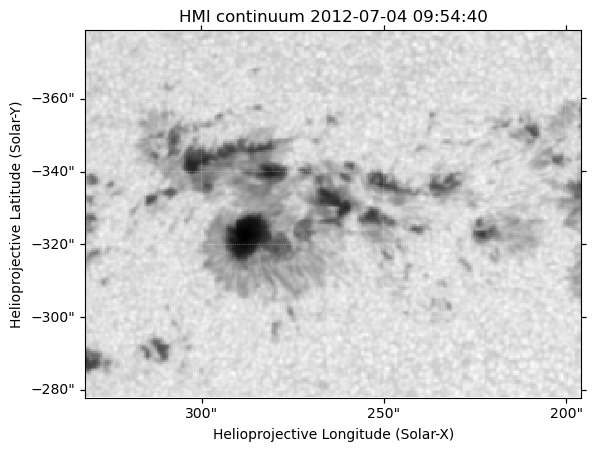

In [23]:
# Define the pixel range
# Convert pixel corners to world coordinates
bottom_left = amap.pixel_to_world(xmin * u.pixel, ymin * u.pixel)
top_right = amap.pixel_to_world((xmax - 1) * u.pixel, (ymax - 1) * u.pixel)

# Extract the submap
submap = amap.submap(bottom_left, top_right=top_right)

# Plot only the submap
fig = plt.figure()
ax = plt.subplot(projection=submap)
submap.plot()
plt.show()

The idea is to develop and algorithm that is capable of detecting approximately this region without having to select it by hand as we just did, or at least be as close as possible to detect it.

Our first try will be using OpenCV.

In [12]:
from skimage import io, transform, exposure
import cv2

directory = Path('/scratchsan/observatorio/juagudeloo/Doctorado/SDO_paper_to_observations/images')
images_name = 'paper_image.png'
paper_img = io.imread(directory / images_name, as_gray=True)  # Paper figure
full_data = np.nan_to_num(amap.data, nan=0.0).astype(np.float32)  # Handles signed mag data
if amap.wavelength.unit == 'G': full_data = np.abs(full_data)  # Mag normalization

original_image = cv2.normalize(np.abs(full_data), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)



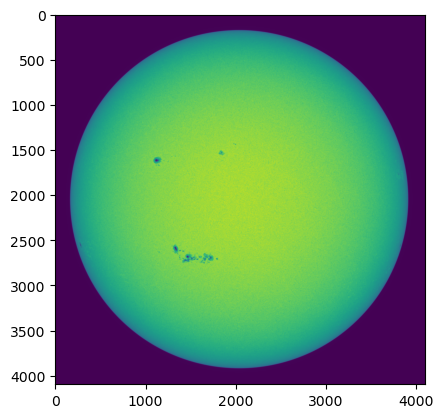

In [13]:
plt.imshow(original_image.astype(np.float32))
plt.savefig('full_normalized_image.png')


Raw images ready. Paper shape: (142, 191), Original: (4096, 4096)
Using SIFT
Using SIFT
Step 3 complete (SIFT/SIFT): 78 keypoints (paper), 155 (original).
Step 4 complete: 3 good matches (strict ratio=0.65).
Too few good matches.


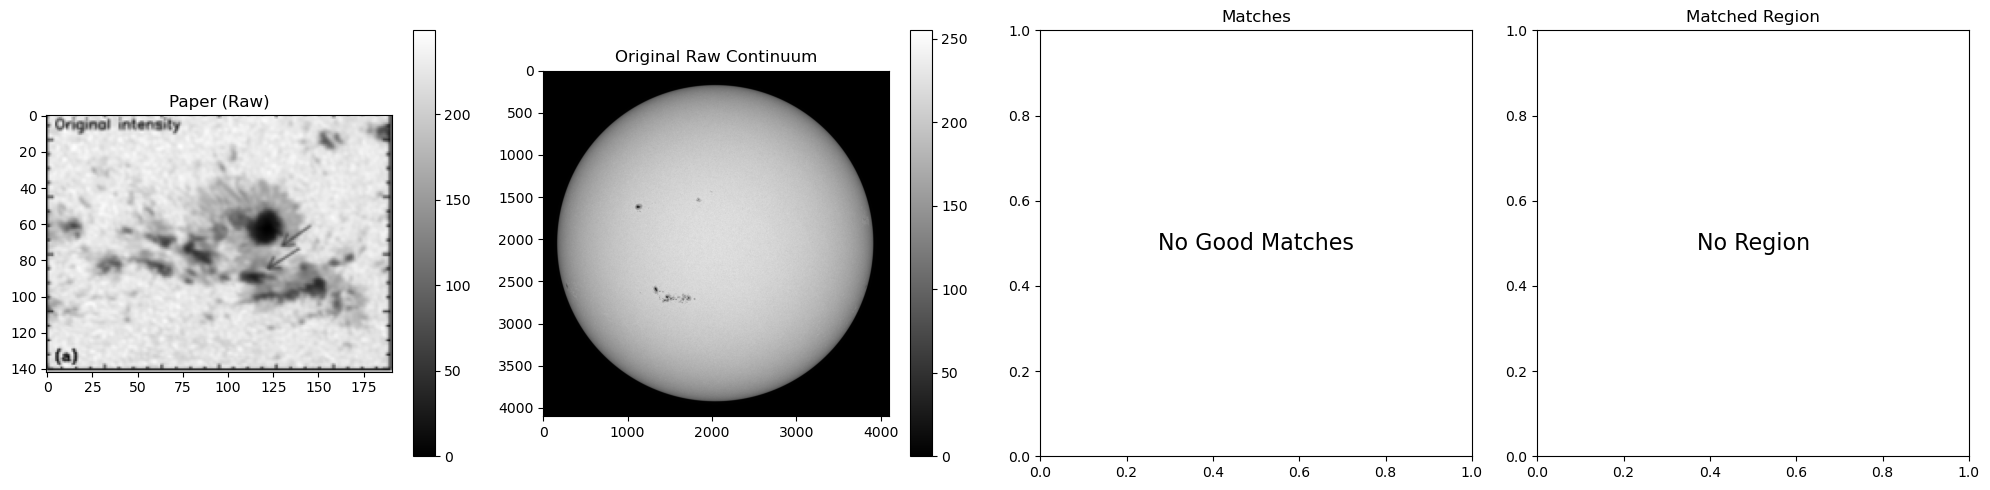

Raw pipeline complete! Check *_raw.jpg files. If still poor → SuperGlue time.


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io  # No exposure.equalize_hist!
# Assume 'amap' and 'paper_img'/'original_image' defined upstream

# Step 1: RAW NORMALIZATION (critical fix!)
def preprocess_raw_continuum(amap_data):
    """Raw HMI continuum: abs(mag) -> normalized uint8, NO histeq"""
    data = np.abs(amap_data).astype(np.float32)
    data = np.nan_to_num(data, nan=0.0)
    return cv2.normalize(data, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Your paper image (keep as-is, but raw preprocess)
paper_gray = paper_img if paper_img.dtype == np.uint8 else (paper_img * 255).astype(np.uint8)

# RAW original (skip equalize_hist!)
original_raw = preprocess_raw_continuum(amap.data)

print(f"Raw images ready. Paper shape: {paper_gray.shape}, Original: {original_raw.shape}")

# Step 2: Better denoising (bilateral preserves sunspot edges)
paper_denoised = cv2.bilateralFilter(paper_gray, 9, 75, 75)
original_denoised = cv2.bilateralFilter(original_raw, 9, 75, 75)

# Step 3: SIFT (more robust) + ORB fallback
def detect_features(img):
    """Try SIFT first, fallback to ORB"""
    try:
        sift = cv2.SIFT_create(nfeatures=3000)
        kp, des = sift.detectAndCompute(img, None)
        print("Using SIFT")
        return kp, des, 'SIFT'
    except:
        orb = cv2.ORB_create(nfeatures=5000, scaleFactor=1.2, nlevels=8)
        kp, des = orb.detectAndCompute(img, None)
        print("Using ORB")
        return kp, des, 'ORB'

kp_paper, des_paper, feat_type_paper = detect_features(paper_denoised)
kp_original, des_original, feat_type_original = detect_features(original_denoised)

print(f"Step 3 complete ({feat_type_paper}/{feat_type_original}): "
      f"{len(kp_paper)} keypoints (paper), {len(kp_original)} (original).")

# Step 4: Adaptive matching (stricter ratio test)
bf = cv2.BFMatcher(cv2.NORM_L2 if 'SIFT' in feat_type_paper else cv2.NORM_HAMMING, crossCheck=False)
matches_all = bf.knnMatch(des_paper, des_original, k=2)

# Stricter ratio test (0.7 -> 0.65) to reject text matches
good_matches = [m for m, n in matches_all if m.distance < 0.65 * n.distance]
print(f"Step 4 complete: {len(good_matches)} good matches (strict ratio=0.65).")

# Step 5: RANSAC (tighter threshold for sunspots)
if len(good_matches) > 10:  # Need more for robust fit
    src_pts = np.float32([kp_paper[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_original[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    
    M_sim, inlier_mask = cv2.estimateAffinePartial2D(src_pts, dst_pts, 
                                                     method=cv2.RANSAC,
                                                     ransacReprojThreshold=3.0,  # Tighter
                                                     confidence=0.995)  # Higher confidence
    
    num_inliers = np.sum(inlier_mask)
    print(f"Step 5 complete: {num_inliers}/{len(good_matches)} inliers ({num_inliers/len(good_matches):.1%}).")
    
    if M_sim is not None and num_inliers > 15:  # Quality threshold
        h_paper, w_paper = paper_gray.shape
        h_orig, w_orig = original_raw.shape  # Use raw dims
        
        # Color for viz
        paper_color = cv2.cvtColor(paper_gray, cv2.COLOR_GRAY2BGR)
        original_color = cv2.cvtColor(original_raw, cv2.COLOR_GRAY2BGR)  # Raw color
        
        warped_paper = cv2.warpAffine(paper_color, M_sim, (w_orig, h_orig))
        overlay = cv2.addWeighted(original_color, 0.7, warped_paper, 0.3, 0)
        
        # Save
        cv2.imwrite('overlay_result_raw.jpg', overlay)
        cv2.imwrite('warped_paper_raw.jpg', warped_paper)
        
        # Matches viz (inliers only)
        good_inliers = [good_matches[i] for i in range(len(good_matches)) if inlier_mask[i]]
        match_img = cv2.drawMatches(paper_color, kp_paper, original_color, kp_original, 
                                    good_inliers[:50], None,
                                    matchColor=(0,255,0), singlePointColor=(255,0,0),
                                    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        cv2.imwrite('match_visualization_raw.jpg', match_img)
        
        print("RAW Results saved: overlay_result_raw.jpg, etc.")
        print("Similarity matrix M:\n", M_sim)
        
        # Parameters
        cos_theta = M_sim[0,0]; sin_theta = M_sim[1,0]
        scale = np.sqrt(cos_theta**2 + sin_theta**2)
        angle_deg = np.degrees(np.arctan2(sin_theta, cos_theta))
        tx, ty = M_sim[0,2], M_sim[1,2]
        print(f"Scale: {scale:.3f}, Rotation: {angle_deg:.1f}°, Translation: ({tx:.1f}, {ty:.1f}) pix")
        
        match_img_exists = True
        M_sim_final = M_sim
        
    else:
        print("RANSAC failed (low inliers) - try SuperGlue next.")
        match_img_exists = False
        M_sim_final = None
else:
    print("Too few good matches.")
    match_img_exists = False
    M_sim_final = None

# Your rectangle/matched region code (unchanged, using M_sim_final)
if M_sim_final is not None:
    h_paper, w_paper = paper_gray.shape
    corners = np.float32([[0, 0], [w_paper, 0], [w_paper, h_paper], [0, h_paper]]).reshape(-1, 1, 2)
    transformed_corners = cv2.transform(corners, M_sim_final)
    transformed_corners = transformed_corners.astype(int)

    original_with_rect = cv2.cvtColor(original_raw, cv2.COLOR_GRAY2BGR)
    cv2.polylines(original_with_rect, [transformed_corners], isClosed=True, color=(0, 255, 0), thickness=3)
    cv2.imwrite('original_with_rectangle_raw.jpg', original_with_rect)

    # Matched region crop
    x_min, x_max = np.min(transformed_corners[:, 0, 0]), np.max(transformed_corners[:, 0, 0])
    y_min, y_max = np.min(transformed_corners[:, 0, 1]), np.max(transformed_corners[:, 0, 1])
    x_min, y_min = max(x_min, 0), max(y_min, 0)
    x_max, y_max = min(x_max, original_raw.shape[1]), min(y_max, original_raw.shape[0])
    matched_region = original_raw[int(y_min):int(y_max), int(x_min):int(x_max)]
    
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(original_with_rect, cv2.COLOR_BGR2RGB))
    plt.title('Detected Region (Raw Continuum)')
    plt.savefig('detected_region_raw.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Matched region cropped: {matched_region.shape}")
else:
    matched_region = None

# Your 4-panel plot (adapted)
plt.figure(figsize=(20, 5))
plt.subplot(141); plt.imshow(paper_gray, cmap='gray'); plt.title('Paper (Raw)'); plt.colorbar()
plt.subplot(142); plt.imshow(original_raw, cmap='gray'); plt.title('Original Raw Continuum'); plt.colorbar()
plt.subplot(143)
if match_img_exists:
    plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    plt.title('Inlier Matches (Green)')
else:
    plt.text(0.5, 0.5, 'No Good Matches', ha='center', va='center', fontsize=16)
    plt.title('Matches')
plt.subplot(144)
if matched_region is not None:
    plt.imshow(matched_region, cmap='gray')
    plt.title('Matched AR Region')
    plt.colorbar()
else:
    plt.text(0.5, 0.5, 'No Region', ha='center', va='center', fontsize=16)
    plt.title('Matched Region')

plt.tight_layout()
plt.savefig('keypoints_matches_region_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print("Raw pipeline complete! Check *_raw.jpg files. If still poor → SuperGlue time.")


It seems like direct matching won't work since the image has annotations on it along with a change in resolution that is completely unknown along with transformations such as rotations and reflections.

Since the plots have all this modifications applied to the original observation, it is necessary to apply a more flexible algorithm, such as the application of a neural network model, for making the match (at least that is what I consider due to the previous try I did).

In [15]:
from lightglue import LightGlue, SuperPoint, DISK, SIFT, ALIKED, DoGHardNet
from lightglue.utils import load_image, rbd

# SuperPoint+LightGlue
extractor = SuperPoint(max_num_keypoints=2048).eval().cuda()  # load the extractor
matcher = LightGlue(features='superpoint').eval().cuda()  # load the matcher

# or DISK+LightGlue, ALIKED+LightGlue or SIFT+LightGlue
extractor = DISK(max_num_keypoints=2048).eval().cuda()  # load the extractor
matcher = LightGlue(features='disk').eval().cuda()  # load the matcher

# load each image as a torch.Tensor on GPU with shape (3,H,W), normalized in [0,1]
image0 = load_image(directory / 'image_0.png').cuda()
image1 = load_image(directory / 'image_1.png').cuda()

# extract local features
feats0 = extractor.extract(image0)  # auto-resize the image, disable with resize=None
feats1 = extractor.extract(image1)

# match the features
matches01 = matcher({'image0': feats0, 'image1': feats1})
feats0, feats1, matches01 = [rbd(x) for x in [feats0, feats1, matches01]]  # remove batch dimension
matches = matches01['matches']  # indices with shape (K,2)
points0 = feats0['keypoints'][matches[..., 0]]  # coordinates in image #0, shape (K,2)
points1 = feats1['keypoints'][matches[..., 1]]  # coordinates in image #1, shape (K,2)

In [16]:
points0

tensor([[ 654.4712,   88.6348],
        [ 587.0063,  111.1530],
        [ 884.9761,  129.9183],
        [ 995.5435,  129.9183],
        [ 427.7144,  148.6835],
        [ 858.7397,  186.2139],
        [ 590.7544,  204.9791],
        [ 733.1802,  204.9791],
        [ 834.3774,  204.9791],
        [ 759.4165,  206.8557],
        [ 665.7153,  221.8678],
        [ 750.0464,  223.7444],
        [ 884.9761,  223.7444],
        [ 791.2749,  280.0400],
        [ 723.8101,  281.9165],
        [ 808.1411,  281.9165],
        [ 819.3853,  281.9165],
        [ 453.9507,  285.6696],
        [ 605.7466,  285.6696],
        [ 720.0620,  287.5461],
        [ 738.8022,  287.5461],
        [ 787.5269,  287.5461],
        [ 725.6841,  300.6818],
        [ 791.2749,  300.6818],
        [ 774.4087,  302.5583],
        [1548.3804,  302.5583],
        [ 740.6763,  304.4348],
        [1559.6245,  323.2000],
        [1658.9478,  383.2487],
        [1525.8921,  403.8904],
        [1512.7739,  418.9026]], device=

This model was applied on images of my IDE for testing it initially, but the idea is to apply it on the observations.